🔄 Step 1: Loading Olist Relational Data Tables...
🔗 Step 2: Merging relational tables into Master Strategy Dataframe...
🧹 Step 3: Executing data hygiene pipeline and parsing timestamps...
🚛 Step 4: Engineering 'Logistics Delay' metrics (Actual vs. Estimated)...
🧮 Step 5: Computing foundational Recency, Frequency, and Monetary scores...
🎯 Step 6: Mapping algorithmic behaviors to corporate strategy categories...

📈 --- MAIN EXECUTIVE ACCOUNT SUMMARY ---
     Strategic_Segment    Recency  Frequency   Monetary  Avg_Delivery_Delay  Avg_Review_Score  Customer_Count  Revenue_Contribution_%
      At-Risk Churners 337.922044   1.013160 5601181.88            0.934850          4.069212           21884                   42.54
Low-Value / Occasional 262.626400   1.014879 4439565.09            0.773972          4.135137           51349                   33.72
            New Buyers  44.842416   1.000000 2456825.17            0.239387          4.307623           17762                   18.66
        

/tmp/ipykernel_364/2850589382.py:134: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=summary, x='Strategic_Segment', y='Monetary', palette='viridis')


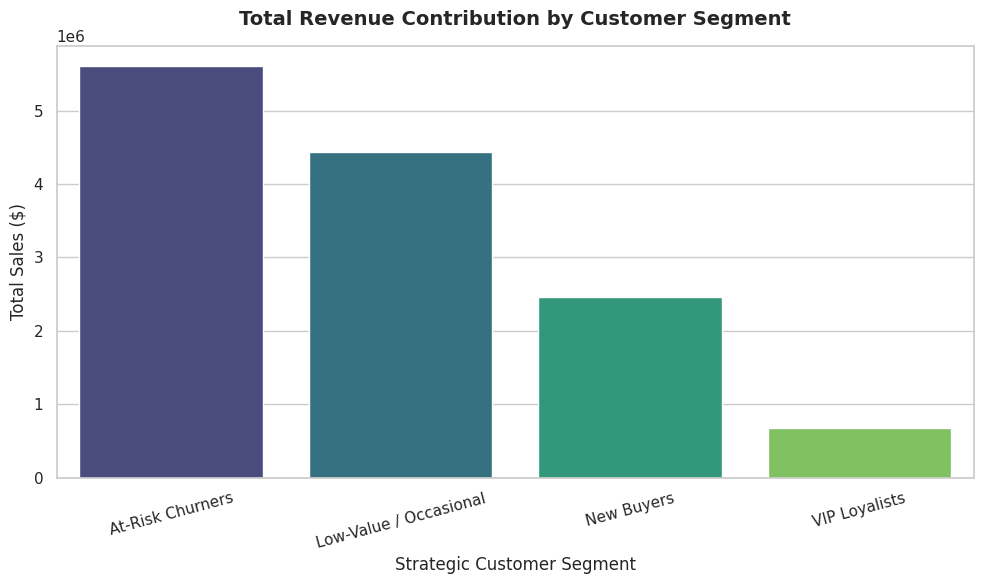

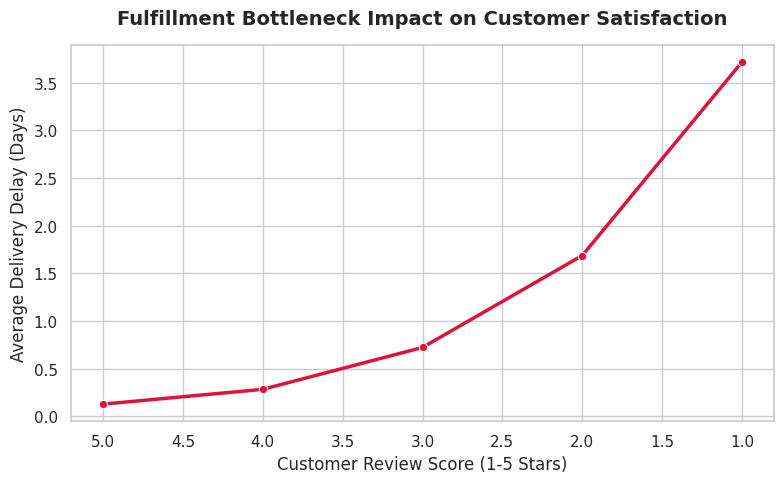

/tmp/ipykernel_364/2850589382.py:157: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=worst_states_plot, y='customer_state', x='delivery_delay_days', palette='Reds_r')


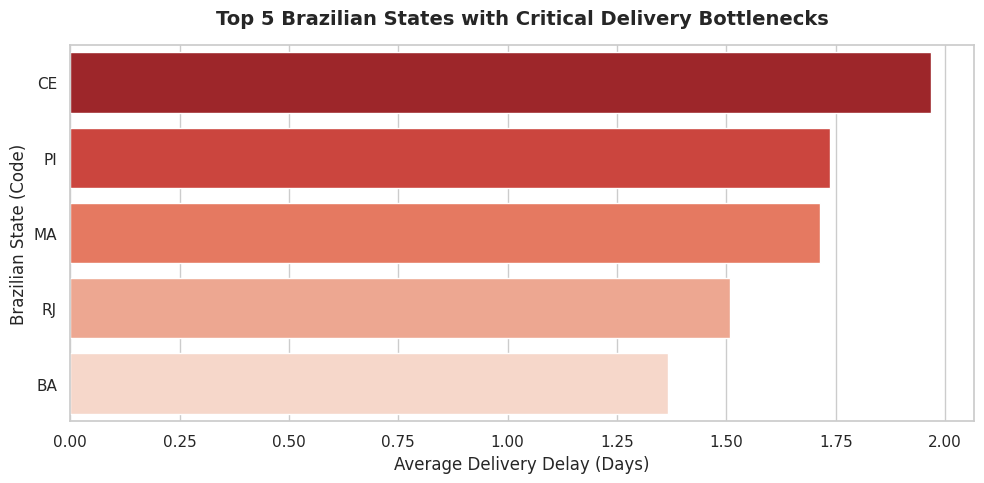


✅ SUCCESS: Full analytics engine executed perfectly.


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# ==============================================================================
# 1. DATA COLLECTION & RELATIONAL MERGING
# ==============================================================================
print("🔄 Step 1: Loading Olist Relational Data Tables...")
try:
    orders = pd.read_csv('olist_orders_dataset.csv')
    items = pd.read_csv('olist_order_items_dataset.csv')
    customers = pd.read_csv('olist_customers_dataset.csv')
    reviews = pd.read_csv('olist_order_reviews_dataset.csv')
    products = pd.read_csv('olist_products_dataset.csv')
except FileNotFoundError as e:
    print(f"\n❌ Error: {e}")
    print("Please ensure all 5 Olist CSV files are uploaded to Colab.")
    raise

print("🔗 Step 2: Merging relational tables into Master Strategy Dataframe...")
df = items.merge(orders, on='order_id', how='inner')
df = df.merge(customers, on='customer_id', how='inner')
df = df.merge(reviews, on='order_id', how='inner')
df = df.merge(products, on='product_id', how='inner')

# ==============================================================================
# 2. DATA CLEANING & OPERATIONAL METRIC CALCULATIONS
# ==============================================================================
print("🧹 Step 3: Executing data hygiene pipeline and parsing timestamps...")
df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
df['order_delivered_customer_date'] = pd.to_datetime(df['order_delivered_customer_date'])
df['order_estimated_delivery_date'] = pd.to_datetime(df['order_estimated_delivery_date'])

# Drop critical data row leaks
df = df.dropna(subset=['customer_unique_id', 'order_delivered_customer_date'])

print("🚛 Step 4: Engineering 'Logistics Delay' metrics (Actual vs. Estimated)...")
df['delivery_delay_days'] = (df['order_delivered_customer_date'] - df['order_estimated_delivery_date']).dt.days
# Normalize early deliveries (negative values) to 0 days late
df['delivery_delay_days'] = df['delivery_delay_days'].apply(lambda x: x if x > 0 else 0)

# ==============================================================================
# 3. RFM BASELINE SCORE GENERATION
# ==============================================================================
print("🧮 Step 5: Computing foundational Recency, Frequency, and Monetary scores...")
snapshot_date = df['order_purchase_timestamp'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (snapshot_date - x.max()).days, # Recency
    'order_id': 'nunique',                                               # Frequency
    'price': 'sum',                                                      # Monetary Value
    'delivery_delay_days': 'mean',                                       # Consulting Add-On 1
    'review_score': 'mean'                                               # Consulting Add-On 2
})

rfm.columns = ['Recency', 'Frequency', 'Monetary', 'Avg_Delivery_Delay', 'Avg_Review_Score']

# ==============================================================================
# 4. STRATEGIC CUSTOMER TIERS ASSIGNMENT
# ==============================================================================
print("🎯 Step 6: Mapping algorithmic behaviors to corporate strategy categories...")
def assign_tier(row):
    if row['Monetary'] >= 150 and row['Frequency'] > 1:
        return 'VIP Loyalists'
    elif row['Monetary'] >= 100 and row['Recency'] > 180:
        return 'At-Risk Churners'
    elif row['Recency'] <= 90 and row['Frequency'] == 1:
        return 'New Buyers'
    else:
        return 'Low-Value / Occasional'

rfm['Strategic_Segment'] = rfm.apply(assign_tier, axis=1)

# Generate baseline consulting summary table
summary = rfm.groupby('Strategic_Segment').agg({
    'Recency': 'mean',
    'Frequency': 'mean',
    'Monetary': 'sum',
    'Avg_Delivery_Delay': 'mean',
    'Avg_Review_Score': 'mean',
    'Strategic_Segment': 'count'
}).rename(columns={'Strategic_Segment': 'Customer_Count'}).reset_index()

total_revenue = summary['Monetary'].sum()
summary['Revenue_Contribution_%'] = round((summary['Monetary'] / total_revenue) * 100, 2)

print("\n📈 --- MAIN EXECUTIVE ACCOUNT SUMMARY ---")
print(summary.to_string(index=False))

# ==============================================================================
# 5. DEEP-DIVE STRATEGY & PANDAS ANALYSIS BLOCKS
# ==============================================================================
print("\n🔍 Step 7: Performing localized and asset-risk deep dives...")

# Deep Dive 1: Regional Shipping Issues
state_delays = df.groupby('customer_state').agg({
    'delivery_delay_days': 'mean',
    'price': 'sum',
    'order_id': 'count'
}).rename(columns={'order_id': 'Total_Orders', 'price': 'Total_Sales'})
state_delays = state_delays[state_delays['Total_Orders'] > 500]
worst_states = state_delays.sort_values(by='delivery_delay_days', ascending=False).head(5)

# Deep Dive 2: Breakpoint Correlation
sentiment_correlation = df.groupby('review_score').agg({
    'delivery_delay_days': 'mean',
    'order_id': 'count'
}).rename(columns={'order_id': 'Total_Reviews'})

# Deep Dive 3: Product Portfolio Value Vulnerabilities
product_analysis = df.groupby('product_category_name').agg({
    'price': 'sum',
    'review_score': 'mean',
    'order_id': 'count'
}).rename(columns={'price': 'Total_Revenue', 'review_score': 'Avg_Review'})
high_revenue_products = product_analysis[product_analysis['Total_Revenue'] > 50000]
vulnerable_products = high_revenue_products.sort_values(by='Avg_Review', ascending=True).head(5)

print("\n📍 --- DEEP DIVE: TOP 5 STATES WITH WORST DELIVERY DELAYS ---")
print(worst_states.to_string())

print("\n📦 --- DEEP DIVE: HIGH-REVENUE PRODUCT VERTICALS AT RISK ---")
print(vulnerable_products.to_string())

# ==============================================================================
# 6. AUTOMATED STRATEGIC VISUALIZATIONS GENERATION
# ==============================================================================
print("\n🎨 Step 8: Rendering and exporting PowerPoint-ready financial and operational charts...")
sns.set_theme(style="whitegrid")

# Graph 1: Revenue Asset Breakdown
plt.figure(figsize=(10, 6))
sns.barplot(data=summary, x='Strategic_Segment', y='Monetary', palette='viridis')
plt.title('Total Revenue Contribution by Customer Segment', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Strategic Customer Segment', fontsize=12)
plt.ylabel('Total Sales ($)', fontsize=12)
plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig('revenue_by_segment.png', dpi=300)
plt.show()

# Graph 2: The Bottleneck Inflection Curve
plt.figure(figsize=(8, 5))
sns.lineplot(data=sentiment_correlation, x='review_score', y='delivery_delay_days', marker='o', color='crimson', linewidth=2.5)
plt.title('Fulfillment Bottleneck Impact on Customer Satisfaction', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Customer Review Score (1-5 Stars)', fontsize=12)
plt.ylabel('Average Delivery Delay (Days)', fontsize=12)
plt.gca().invert_xaxis()
plt.tight_layout()
plt.savefig('delivery_delay_vs_review.png', dpi=300)
plt.show()

# Graph 3: Regional Risk Analysis
plt.figure(figsize=(10, 5))
worst_states_plot = worst_states.reset_index()
sns.barplot(data=worst_states_plot, y='customer_state', x='delivery_delay_days', palette='Reds_r')
plt.title('Top 5 Brazilian States with Critical Delivery Bottlenecks', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Average Delivery Delay (Days)', fontsize=12)
plt.ylabel('Brazilian State (Code)', fontsize=12)
plt.tight_layout()
plt.savefig('worst_regional_delays.png', dpi=300)
plt.show()

# Export final granular dataset
rfm.to_csv('olist_customer_segmentation_results.csv')
print("\n✅ SUCCESS: Full analytics engine executed perfectly.")